<a href="https://colab.research.google.com/github/Neyker8a/challenge2-parte2/blob/main/Challenge2_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inicio carga de datos  

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler




# Carga del CSV desde mi git
df = pd.read_csv("https://raw.githubusercontent.com/Neyker8a/challenge2-parte2/refs/heads/main/datos_tratados.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7032 non-null   object 
 1   churn                      7032 non-null   int64  
 2   customer_gender            7032 non-null   object 
 3   customer_seniorcitizen     7032 non-null   int64  
 4   customer_partner           7032 non-null   object 
 5   customer_dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_phoneservice         7032 non-null   object 
 8   phone_multiplelines        7032 non-null   object 
 9   internet_internetservice   7032 non-null   object 
 10  internet_onlinesecurity    7032 non-null   object 
 11  internet_onlinebackup      7032 non-null   object 
 12  internet_deviceprotection  7032 non-null   object 
 13  internet_techsupport       7032 non-null   objec

# Eliminación de Columnas Irrelevantes

In [17]:
df = df.drop(columns=["customerid"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7032 non-null   int64  
 1   customer_gender            7032 non-null   object 
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   object 
 4   customer_dependents        7032 non-null   object 
 5   customer_tenure            7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   object 
 7   phone_multiplelines        7032 non-null   object 
 8   internet_internetservice   7032 non-null   object 
 9   internet_onlinesecurity    7032 non-null   object 
 10  internet_onlinebackup      7032 non-null   object 
 11  internet_deviceprotection  7032 non-null   object 
 12  internet_techsupport       7032 non-null   object 
 13  internet_streamingtv       7032 non-null   objec

In [18]:
df = pd.get_dummies(df, drop_first=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   churn                                          7032 non-null   int64  
 1   customer_seniorcitizen                         7032 non-null   int64  
 2   customer_tenure                                7032 non-null   int64  
 3   account_charges_monthly                        7032 non-null   float64
 4   account_charges_total                          7032 non-null   float64
 5   cuentas_diarias                                7032 non-null   float64
 6   customer_gender_male                           7032 non-null   bool   
 7   customer_partner_yes                           7032 non-null   bool   
 8   customer_dependents_yes                        7032 non-null   bool   
 9   phone_phoneservice_yes                         7032 

Conversion de booleanos a enteros para mejores resultados en los modelos

In [19]:
df = df.astype(int)

Verificación de la Proporción de Cancelación (Churn)


In [20]:
df["churn"].value_counts()

,count
churn,
0,5163
1,1869


In [21]:
df["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.734215
1,0.265785


El dataset presenta un desbalance moderado. Aproximadamente el 73% de los clientes permanecen activos mientras que el 27% han cancelado el servicio. Este desbalance debe considerarse al evaluar los modelos predictivos, ya que podría afectar las métricas de clasificación.

**Balanceo**: El conjunto de datos presenta un desbalance moderado entre las clases. Aproximadamente tres cuartas partes de los clientes permanecen activos mientras que cerca de una cuarta parte cancelan el servicio. Aunque existe cierta diferencia entre las clases, el desbalance no es extremo, por lo que se decidió continuar con el modelado sin aplicar técnicas de balanceo en esta etapa.

# Normalización o Estandarización

In [22]:
df.describe()

,churn,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias,customer_gender_male,customer_partner_yes,customer_dependents_yes,phone_phoneservice_yes,...,internet_streamingtv_no internet service,internet_streamingtv_yes,internet_streamingmovies_no internet service,internet_streamingmovies_yes,account_contract_one year,account_contract_two year,account_paperlessbilling_yes,account_paymentmethod_credit card (automatic),account_paymentmethod_electronic check,account_paymentmethod_mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.332480,2282.830489,1.601536,0.504693,0.482509,0.298493,0.903299,...,0.216155,0.384386,0.216155,0.388367,0.209329,0.239619,0.592719,0.216297,0.336320,0.228100
std,0.441782,0.368844,24.545260,30.088668,2266.768490,1.097411,0.500014,0.499729,0.457629,0.295571,...,0.411650,0.486484,0.411650,0.487414,0.406858,0.426881,0.491363,0.411748,0.472483,0.419637
min,0.000000,0.000000,1.000000,18.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,9.000000,35.000000,401.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,29.000000,70.000000,1397.000000,2.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,55.000000,89.000000,3794.250000,2.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,72.000000,118.000000,8684.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


realizo un análisis de las variables numéricas utilizando el método **describe()** de pandas. A partir de esta exploración se observó que las variables presentan escalas muy diferentes. Por ejemplo, la variable **account_charges_total** alcanza valores máximos cercanos a **8684**, mientras que **customer_tenure** tiene valores máximos de **72** y **cuentas_diarias** apenas llega a **3**.

Por a estas diferencias en las escalas, se aplica estandarización a los datos con el objetivo de evitar que las variables con valores más altos dominen el entrenamiento de los modelos. Este paso es especialmente importante para algoritmos basados en distancia como la regresión logística.

In [23]:
X = df.drop("churn", axis=1)
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

uso StandardScaler para transformar las variables a una escala común con media 0 y desviación estándar 1. Este proceso facilita el entrenamiento de modelos de machine learning que son sensibles a la escala de los datos.

# Correlación y Selección de Variables

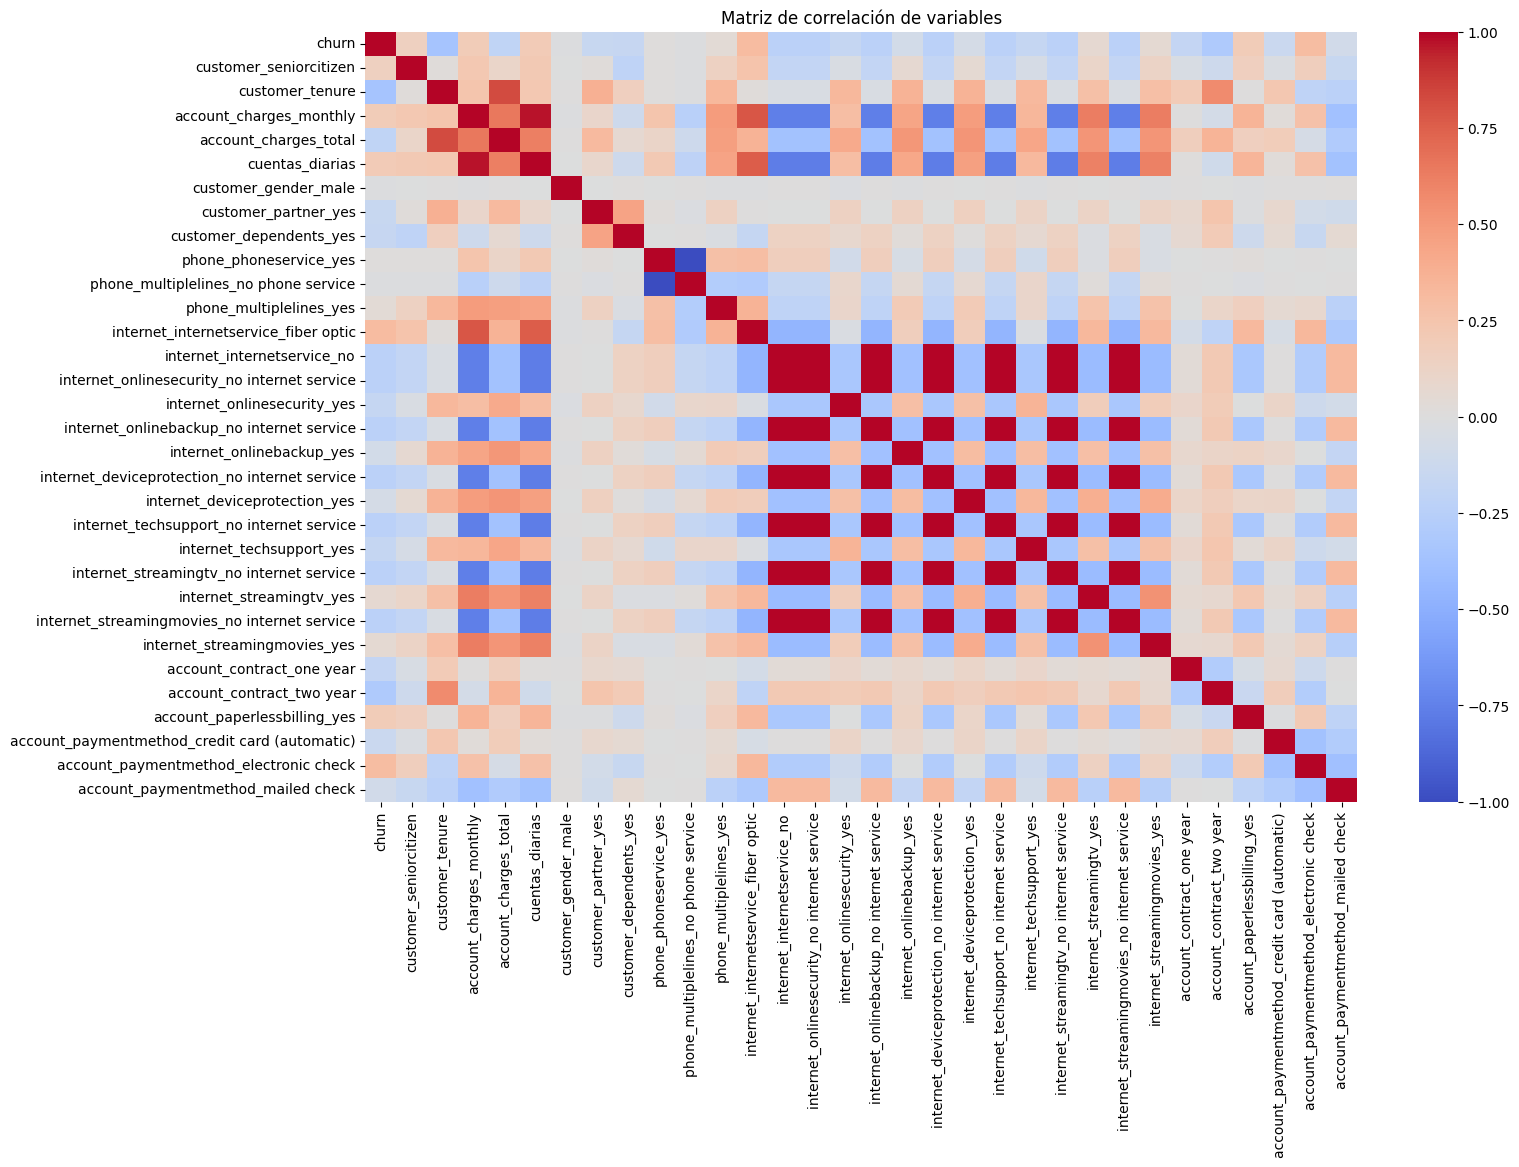

In [24]:
correlation_matrix = df.corr()
plt.figure(figsize=(16,10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Matriz de correlación de variables")
plt.show()

In [25]:
df.corr()["churn"].sort_values(ascending=False)

,churn
churn,1.000000
internet_internetservice_fiber optic,0.307463
account_paymentmethod_electronic check,0.301455
cuentas_diarias,0.195594
account_charges_monthly,0.192922
account_paperlessbilling_yes,0.191454
customer_seniorcitizen,0.150541
internet_streamingtv_yes,0.063254
internet_streamingmovies_yes,0.060860
phone_multiplelines_yes,0.040033


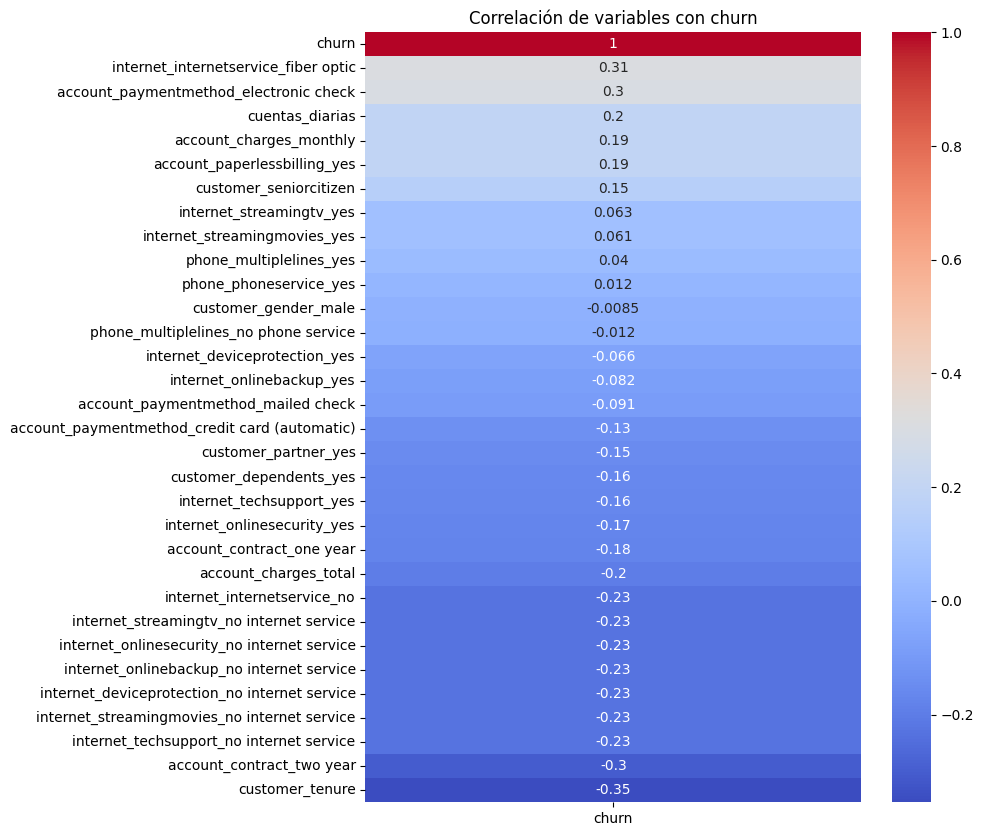

In [26]:
plt.figure(figsize=(8,10))
sns.heatmap(df.corr()[["churn"]].sort_values(by="churn", ascending=False),
            annot=True,
            cmap="coolwarm")

plt.title("Correlación de variables con churn")
plt.show()

Se analizó la matriz de correlación entre las variables numéricas y la variable objetivo churn con el fin de identificar posibles relaciones relevantes para el modelo predictivo.

Los resultados muestran que variables como **customer_tenure** (-0.35) y **account_contract_two_year** (-0.30) presentan una correlación negativa moderada con la cancelación, lo que indica que los clientes con mayor tiempo en la empresa o con contratos más largos tienen menor probabilidad de cancelar el servicio.

Por otro lado, variables como **internet_internetservice_fiber_optic** (0.31) y **account_paymentmethod_electronic_check** (0.30) presentan correlación positiva con el churn, lo que sugiere que estos perfiles de clientes tienden a cancelar con mayor frecuencia.

# Análisis Dirigido

variables específicas que se relacionan con la cancelación

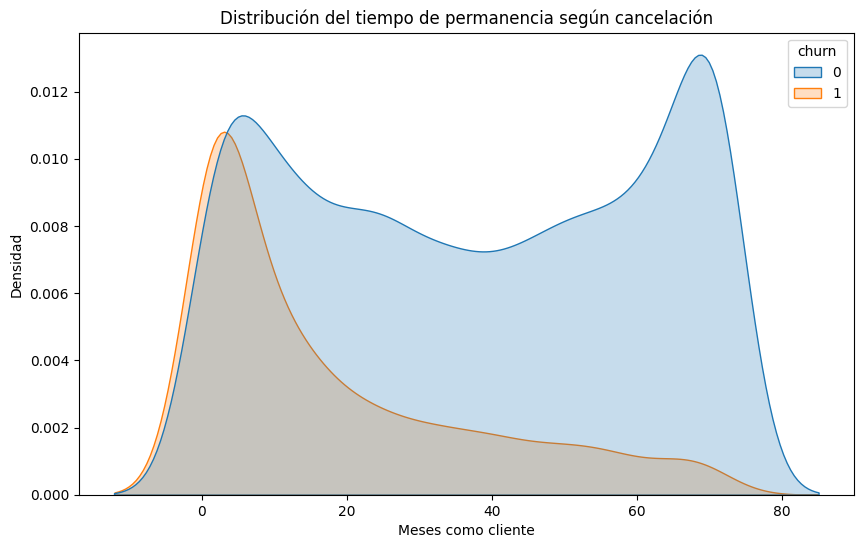

In [27]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="customer_tenure",
    hue="churn",
    fill=True,
    # common_norm=False,
    # alpha=0.5
)

plt.title("Distribución del tiempo de permanencia según cancelación")
plt.xlabel("Meses como cliente")
plt.ylabel("Densidad")

plt.show()



Vemos que los clientes que cancelaron el servicio presentan, en promedio, un menor tiempo de permanencia en la empresa en comparación con los clientes que continúan activos. Esto sugiere que la probabilidad de cancelación es mayor durante las primeras etapas de la relación con el cliente.

### Relación entre el Servicio de Internet (Fibra Óptica) y la Cancelación (`churn`)

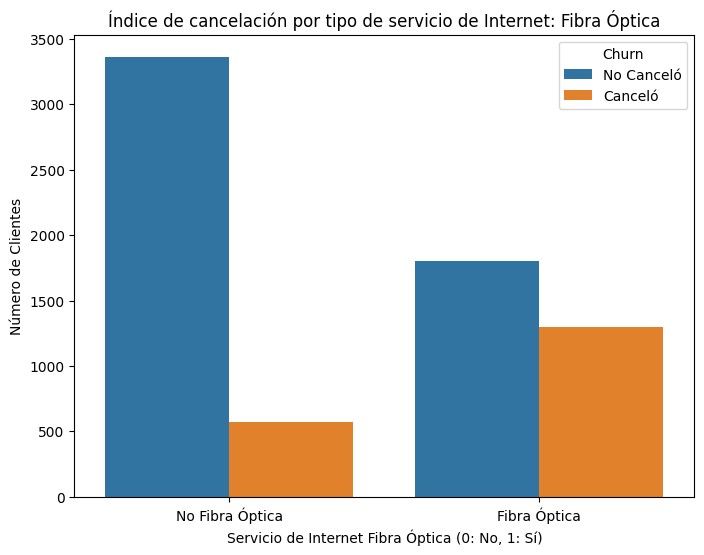

In [37]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="internet_internetservice_fiber optic", hue="churn")
plt.title("Índice de cancelación por tipo de servicio de Internet: Fibra Óptica")
plt.xlabel("Servicio de Internet Fibra Óptica")
plt.ylabel("Número de Clientes")
plt.xticks(ticks=[0, 1], labels=["No Fibra Óptica", "Fibra Óptica"])
plt.legend(title="Churn", labels=["No Canceló", "Canceló"])

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

### Relación entre el Método de Pago (Cheque Electrónico) y la Cancelación (`churn`)

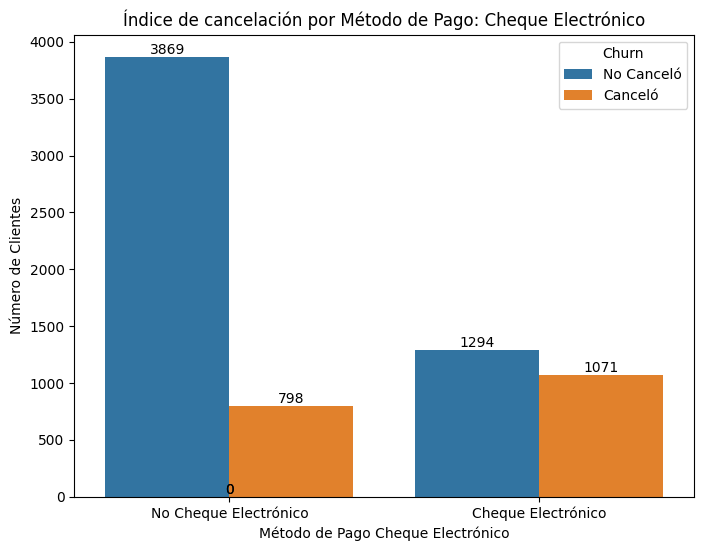

In [38]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x="account_paymentmethod_electronic check", hue="churn")
plt.title("Índice de cancelación por Método de Pago: Cheque Electrónico")
plt.xlabel("Método de Pago Cheque Electrónico")
plt.ylabel("Número de Clientes")
plt.xticks(ticks=[0, 1], labels=["No Cheque Electrónico", "Cheque Electrónico"])
plt.legend(title="Churn", labels=["No Canceló", "Canceló"])

# agregar valores encima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 25,int(height),ha="center")

plt.show()

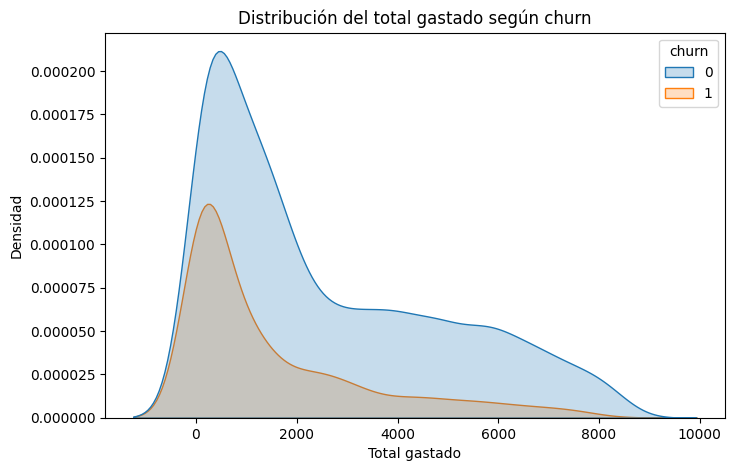

In [30]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="account_charges_total",
    hue="churn",
    fill=True
)

plt.title("Distribución del total gastado según churn")
plt.xlabel("Total gastado")
plt.ylabel("Densidad")

plt.show()

Vemos que los clientes que cancelan el servicio tienden a presentar un gasto total menor en comparación con los clientes que permanecen activos. Esto se relaciona con el tiempo de permanencia, ya que los clientes que cancelan suelen hacerlo en etapas tempranas del servicio.

# Separación de Datos